
=== 0.4 kV ===
U_LL,s = 400.0 V
I(10°C) = 200.0 A
cos(phi)(10°C) = 0.950
R20_kabel = 0.030000 ohm
X_kabel = 0.008000 ohm
Beräknad fast last: Z_load = 1.068175 + j0.352555 ohm

Vid 10 °C:
  R_kabel(10)      = 0.028791 ohm
  I_exact(10)      = 200.000000 A
  Vr_LL_exact(10)  = 389.66 V
  Vr_ang_exact(10) = 0.070801 deg
  P_loss(10)       = 3454.92 W

Vid 90 °C:
  R_kabel(90)      = 0.038463 ohm
  I_exact(90)      = 198.420418 A
  Vr_LL_exact(90)  = 386.58 V
  Vr_ang_exact(90) = 0.219473 deg
  P_loss(90)       = 4542.94 W

Skillnad 10 -> 90 °C:
  Delta I          = -1.579582 A
  Delta Vr_LL      = -3.08 V
  Delta Vr_ang     = 0.148672 deg
  Delta P_loss     = 1088.02 W

=== 11 kV ===
U_LL,s = 11000.0 V
I(10°C) = 200.0 A
cos(phi)(10°C) = 0.950
R20_kabel = 0.800000 ohm
X_kabel = 0.450000 ohm
Beräknad fast last: Z_load = 29.398792 + j9.465266 ohm

Vid 10 °C:
  R_kabel(10)      = 0.767760 ohm
  I_exact(10)      = 200.000000 A
  Vr_LL_exact(10)  = 10698.86 V
  Vr_ang_exact(10) = -0.348335 deg

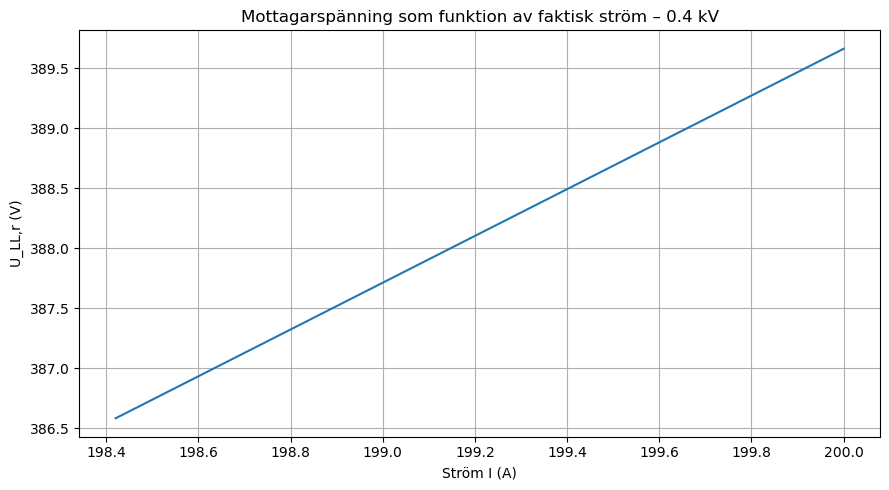

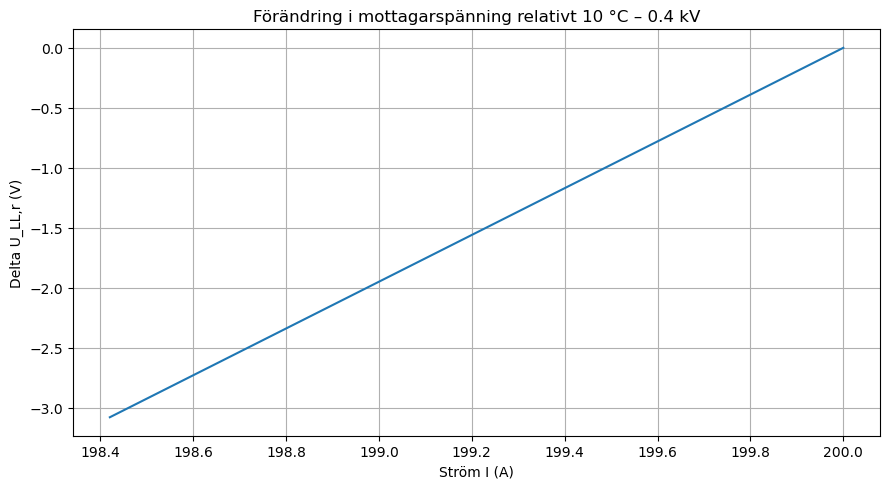

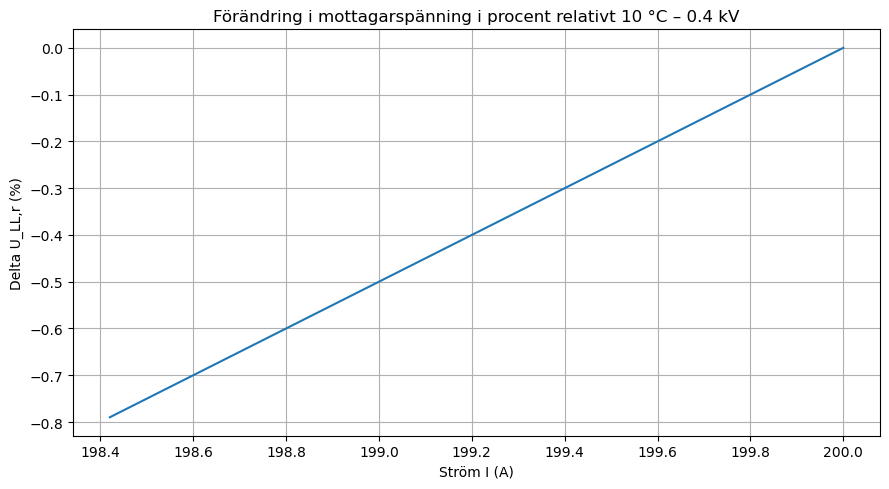

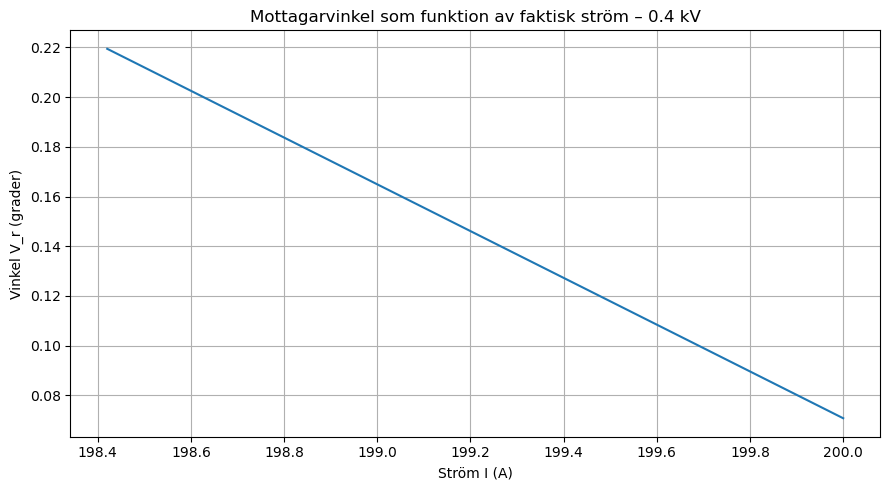

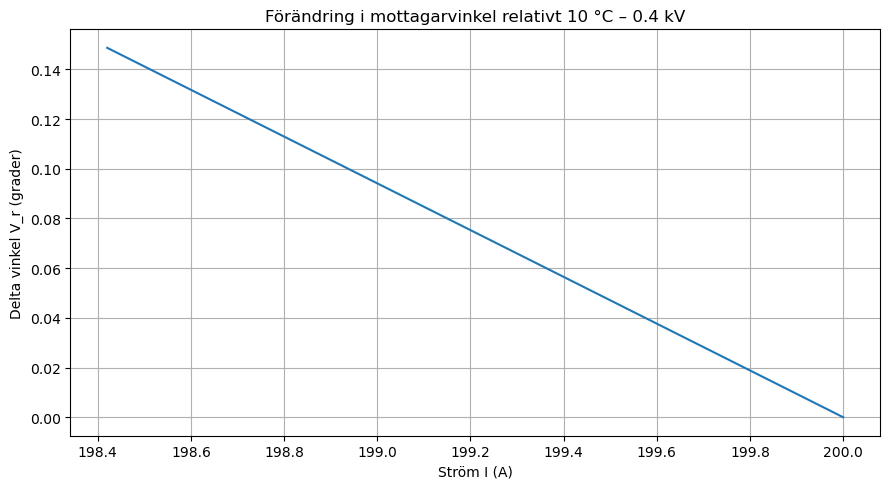

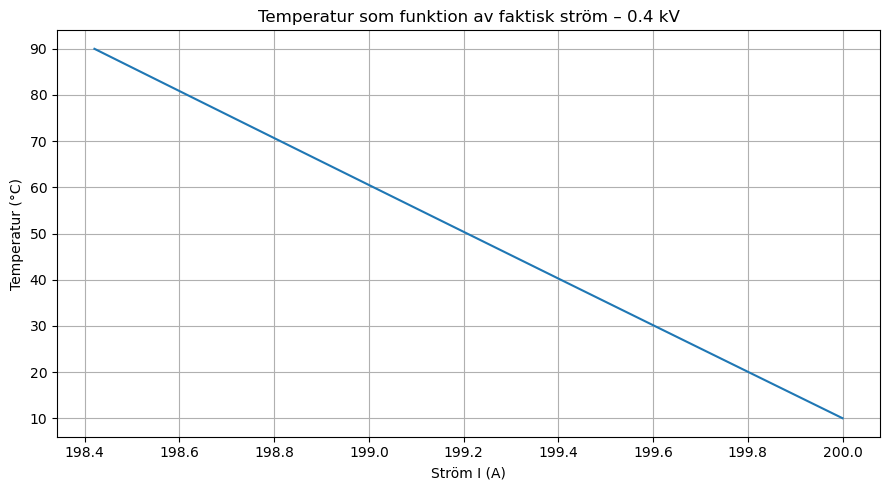

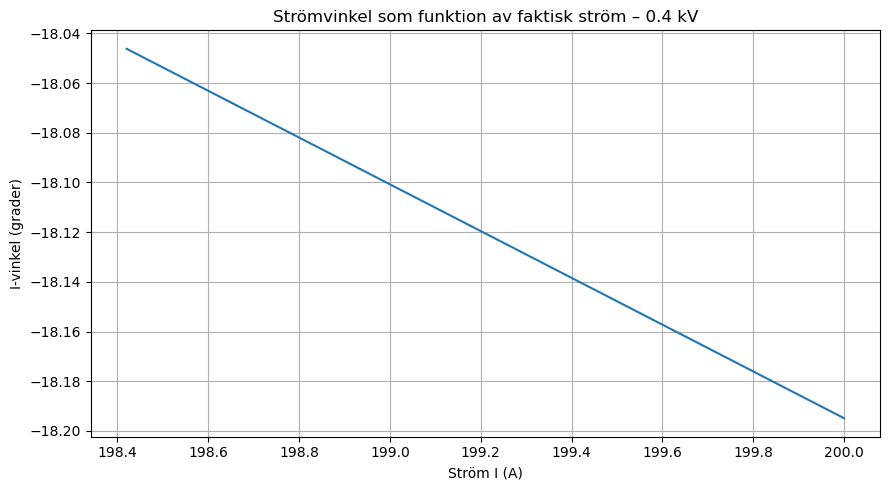

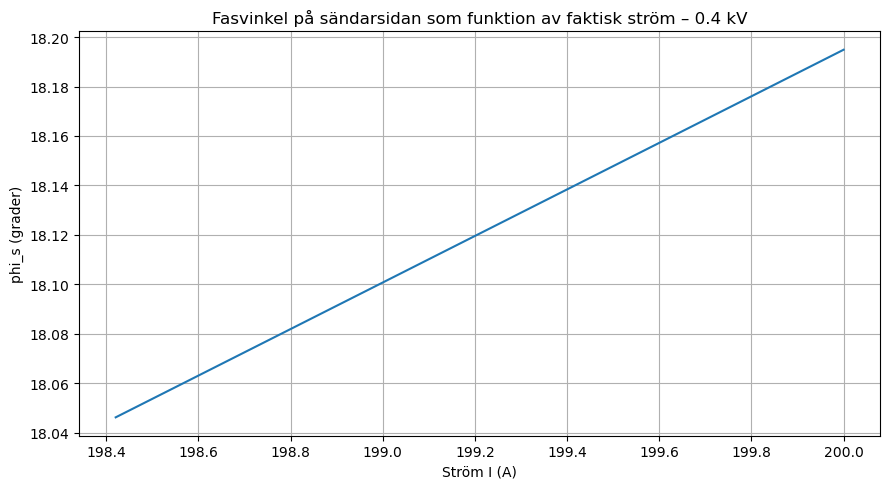

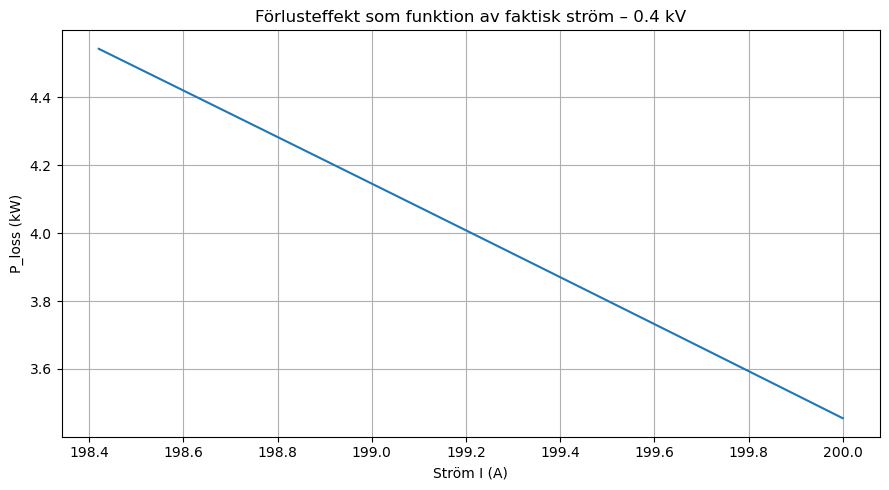

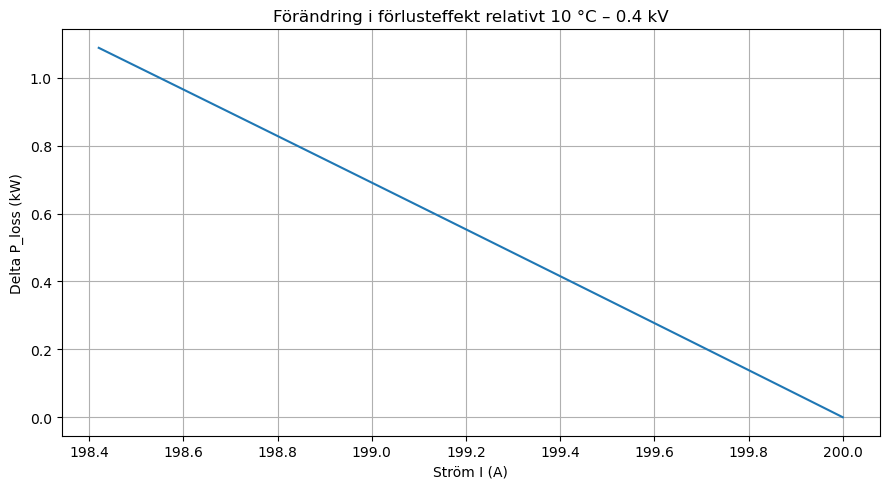

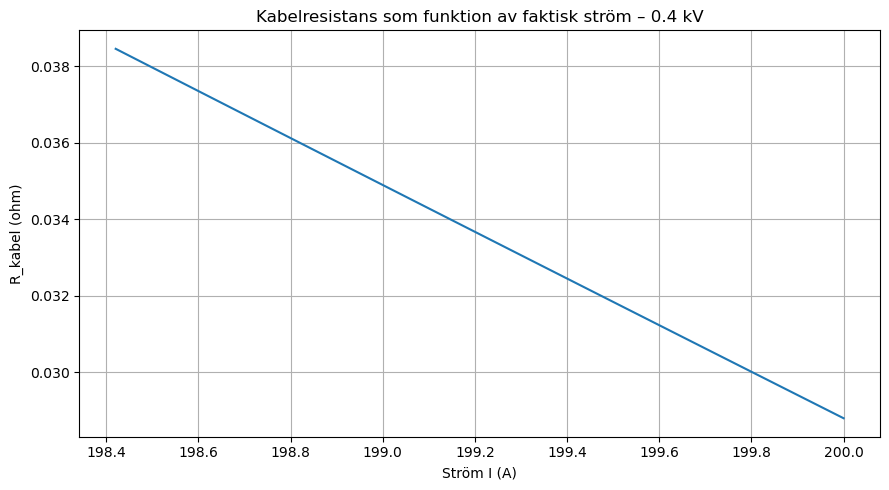

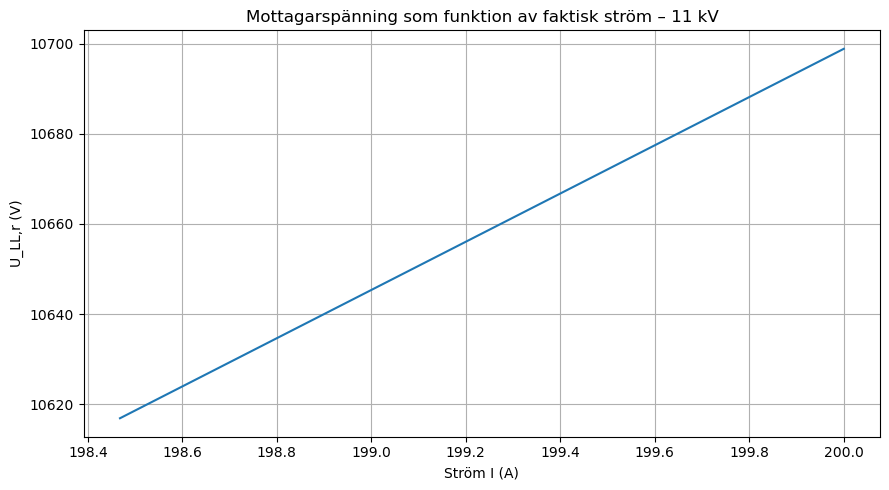

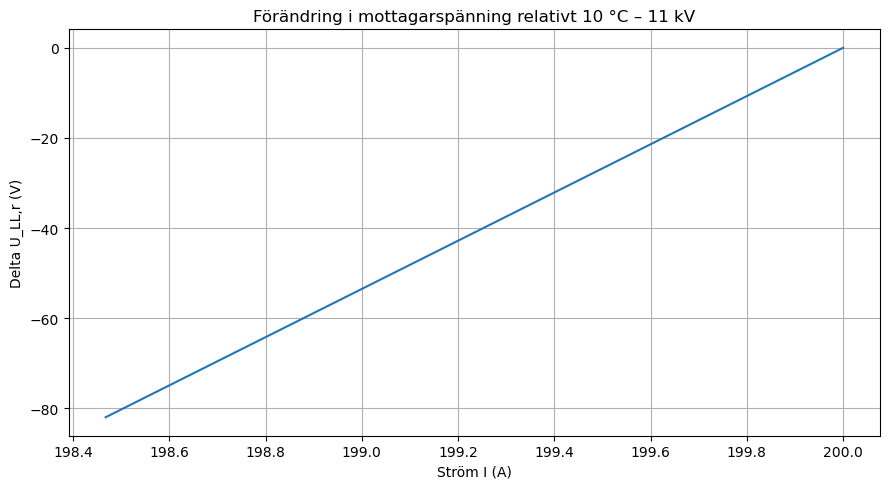

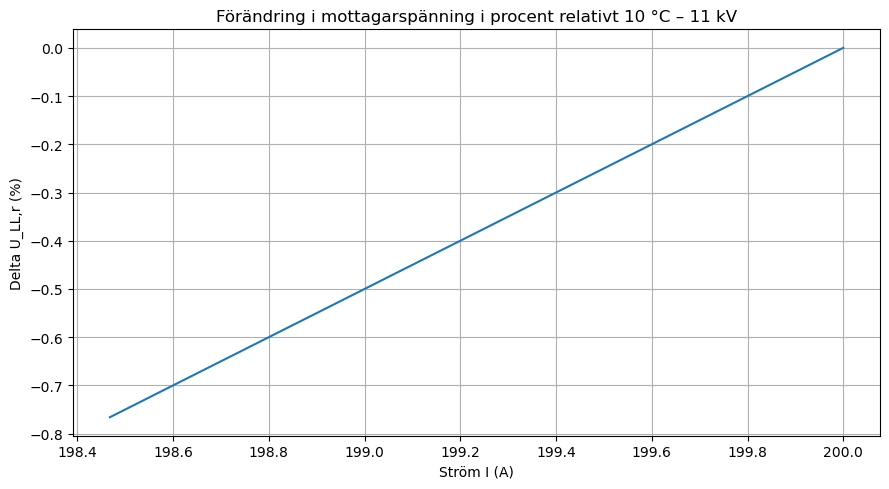

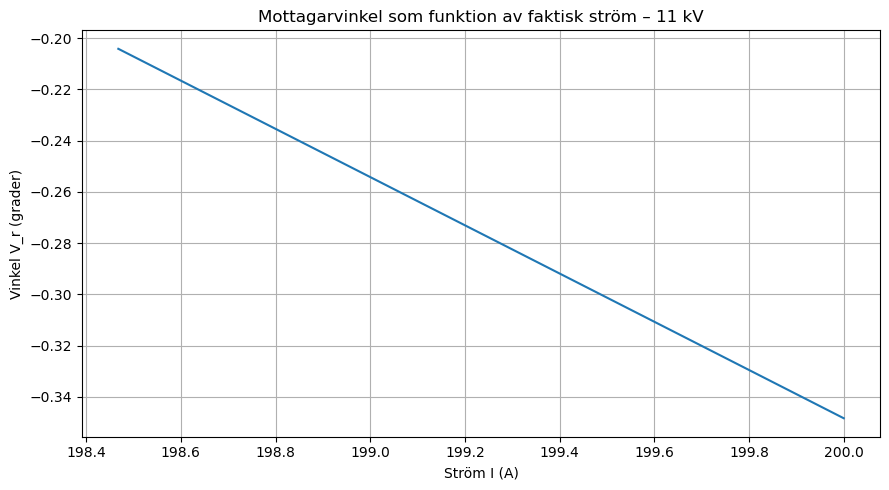

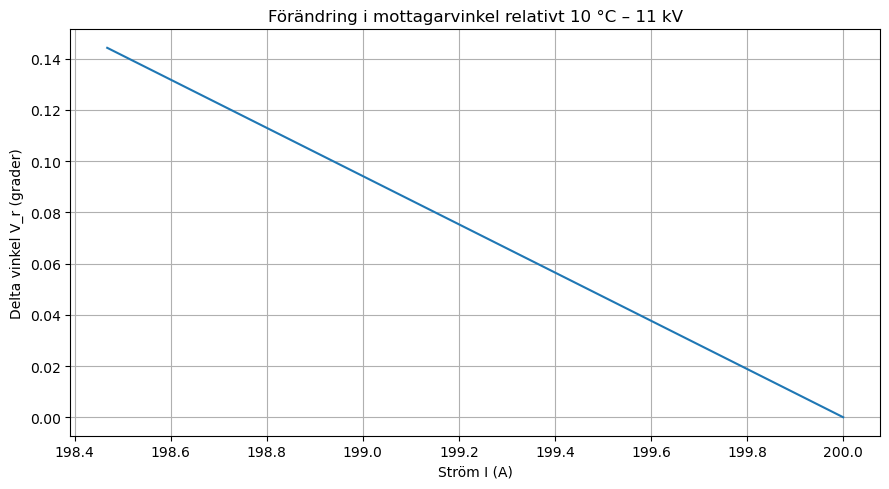

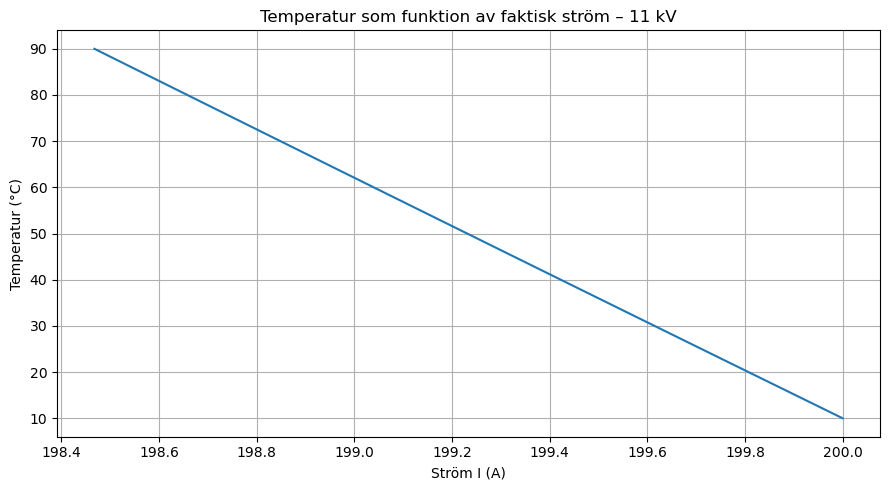

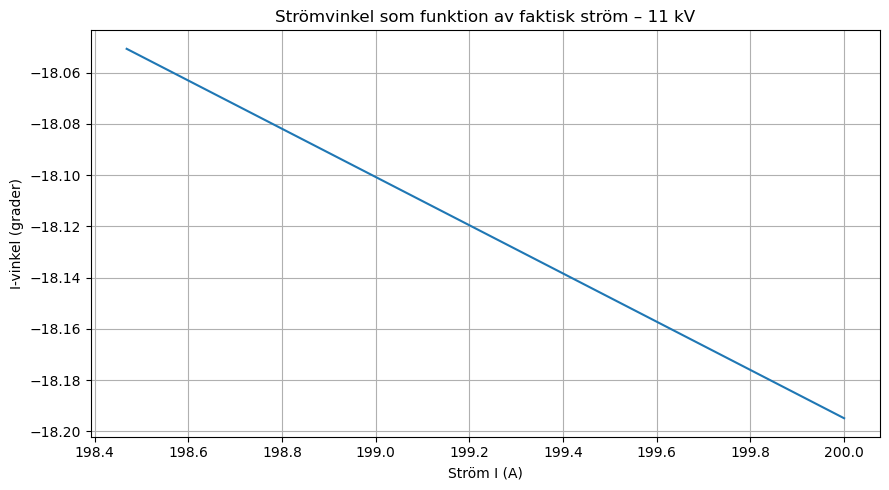

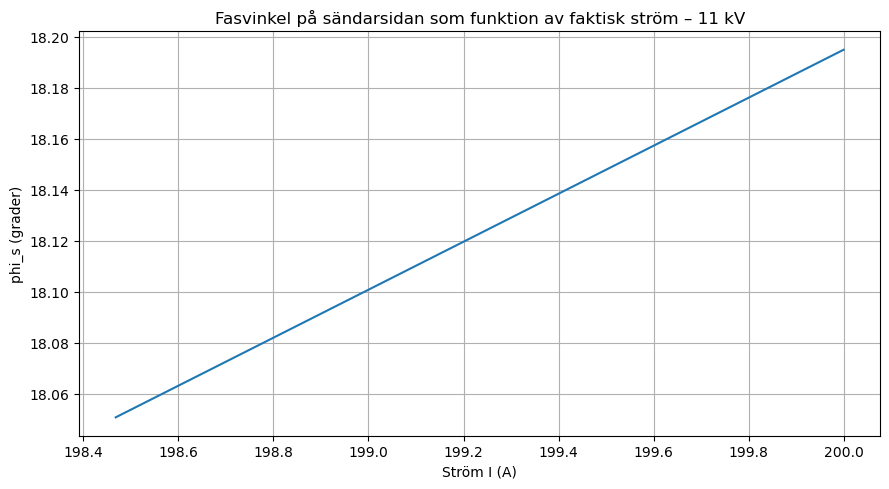

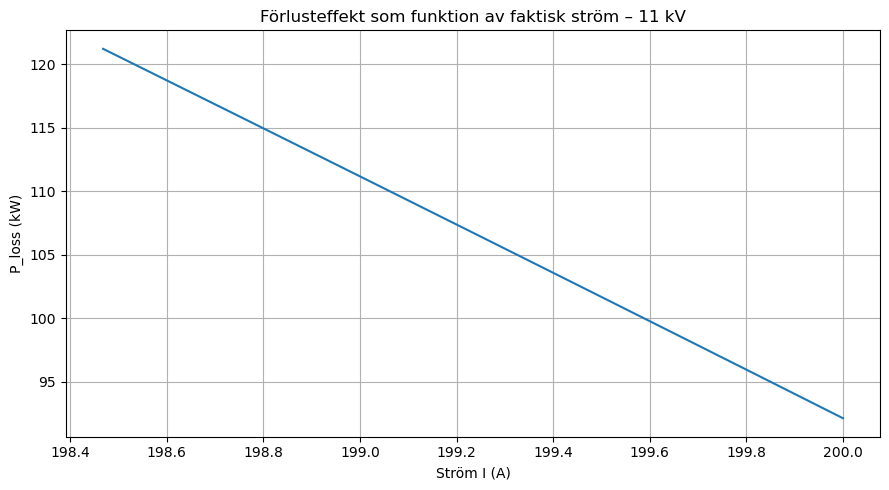

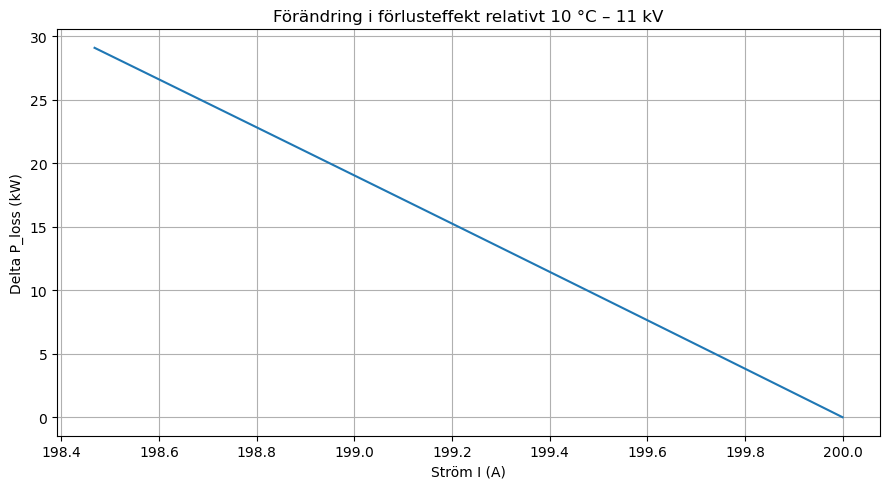

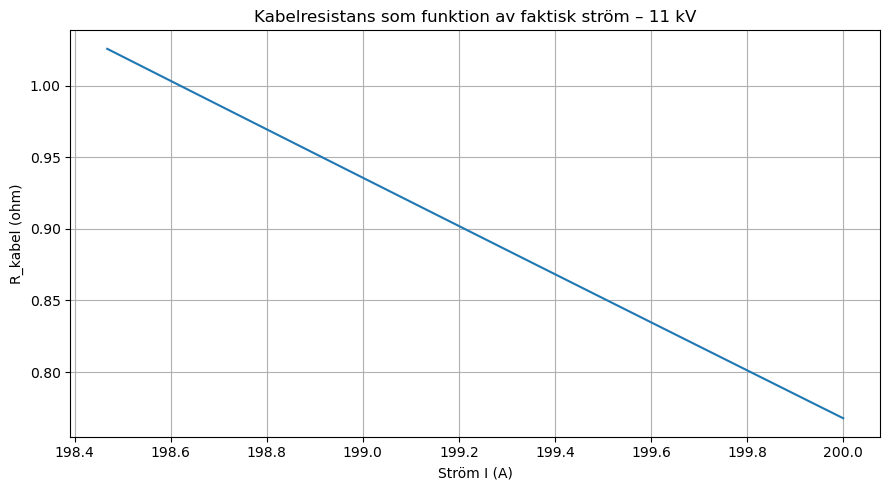

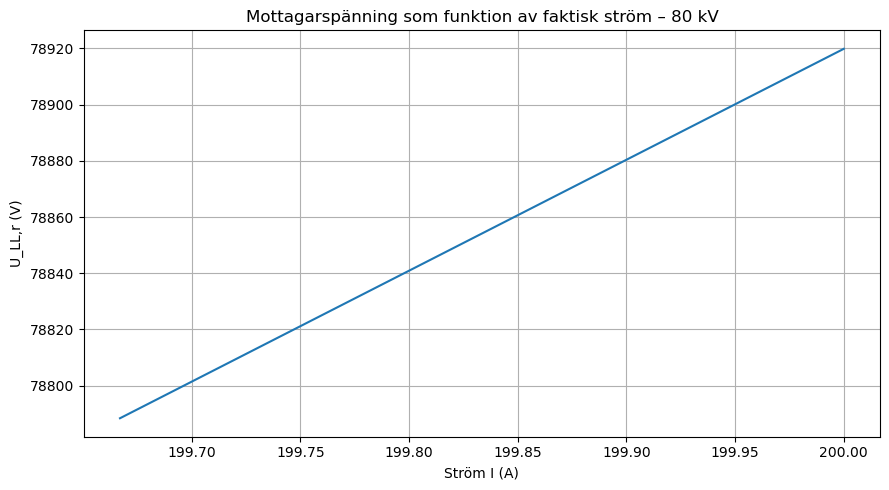

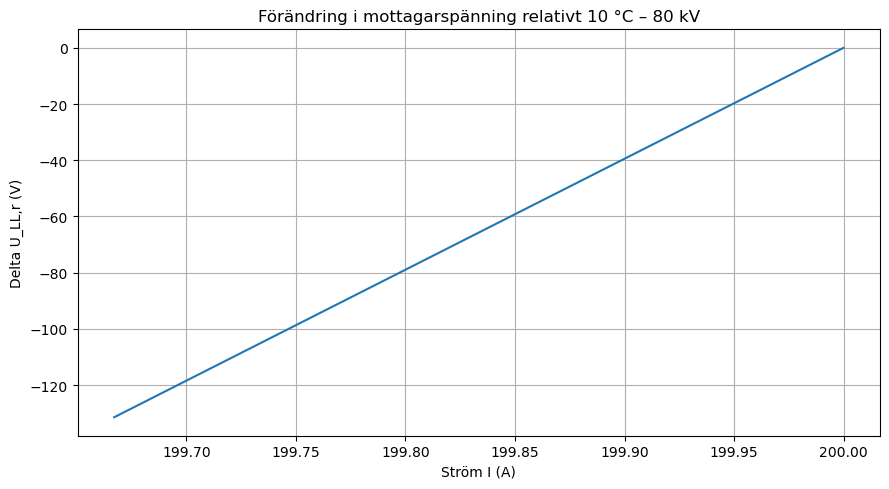

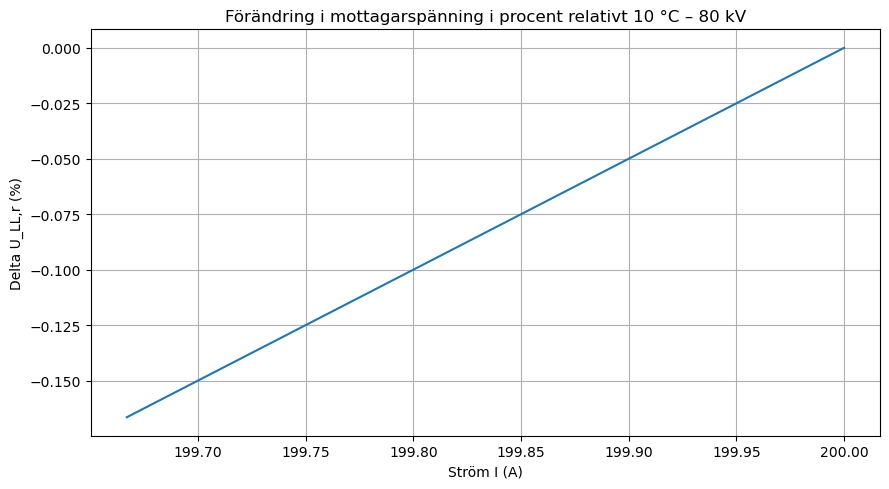

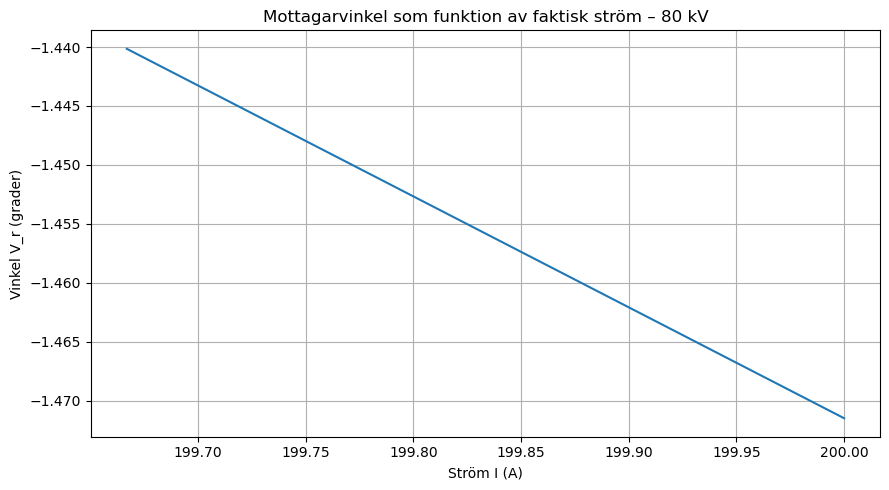

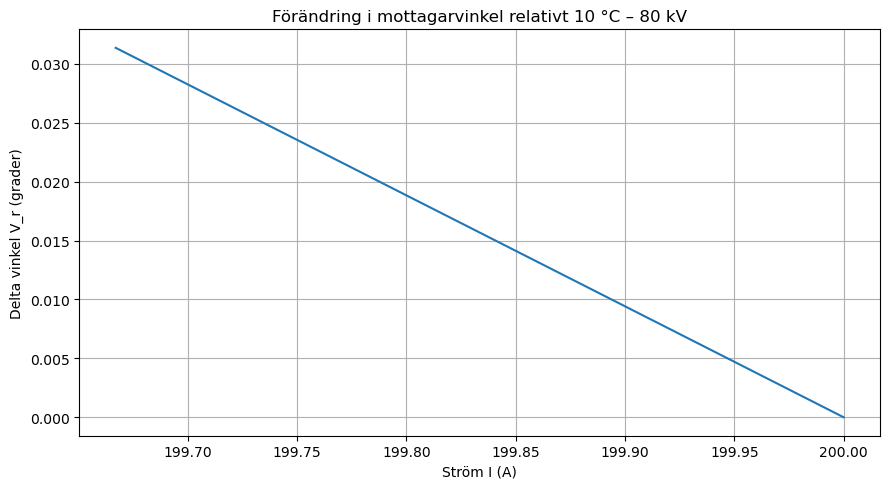

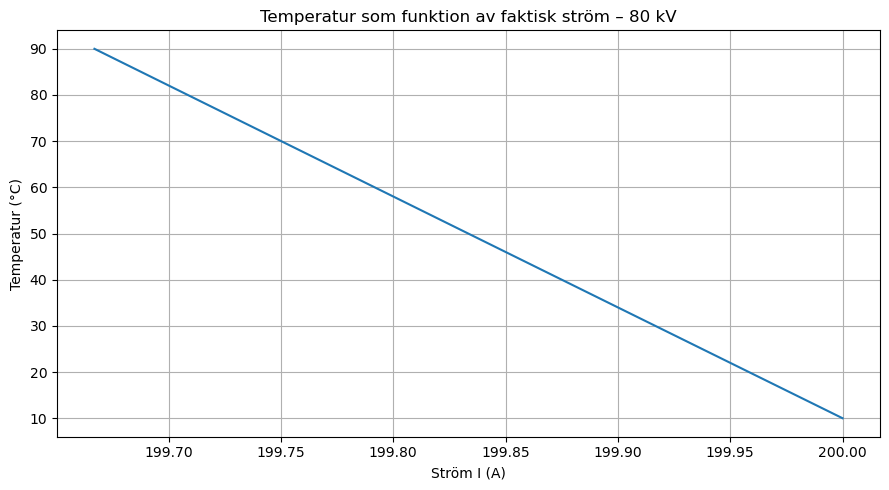

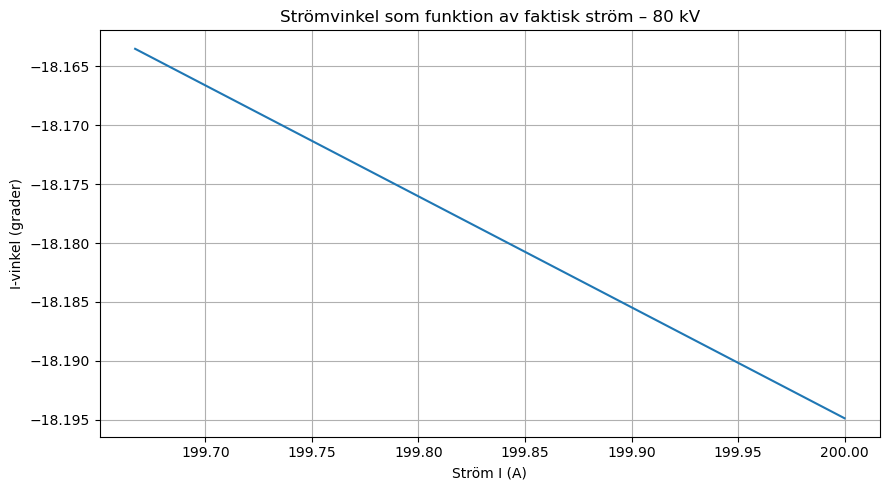

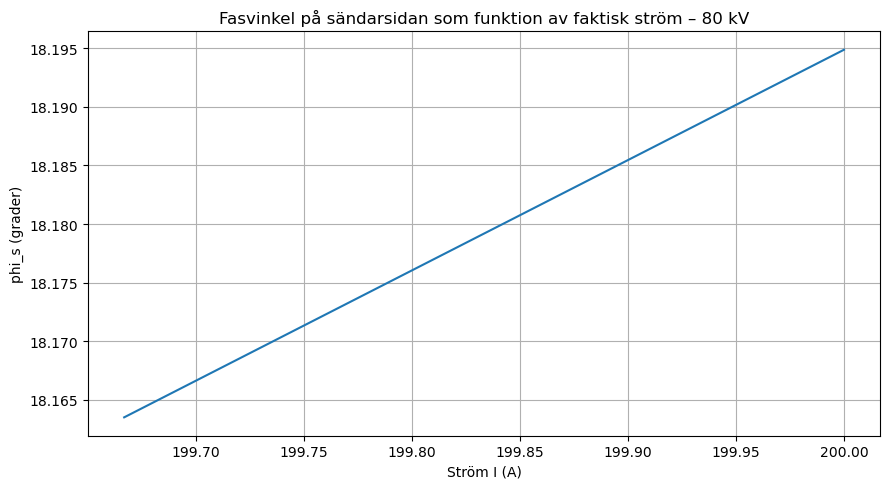

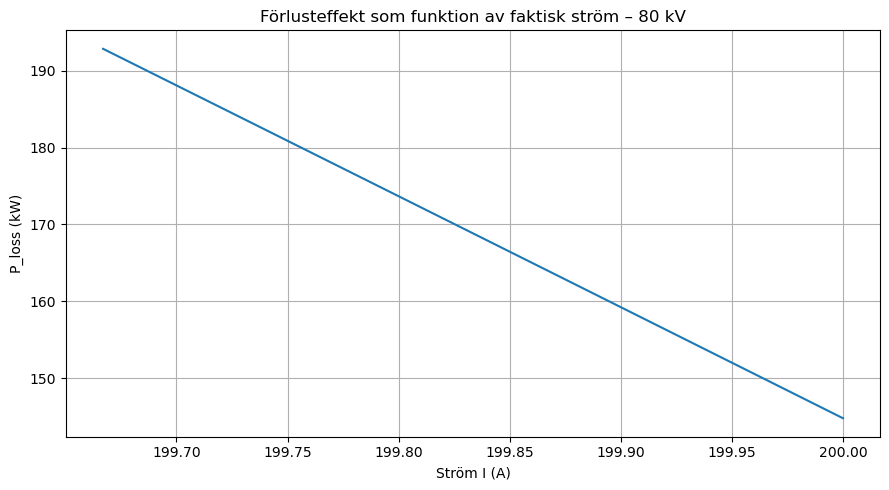

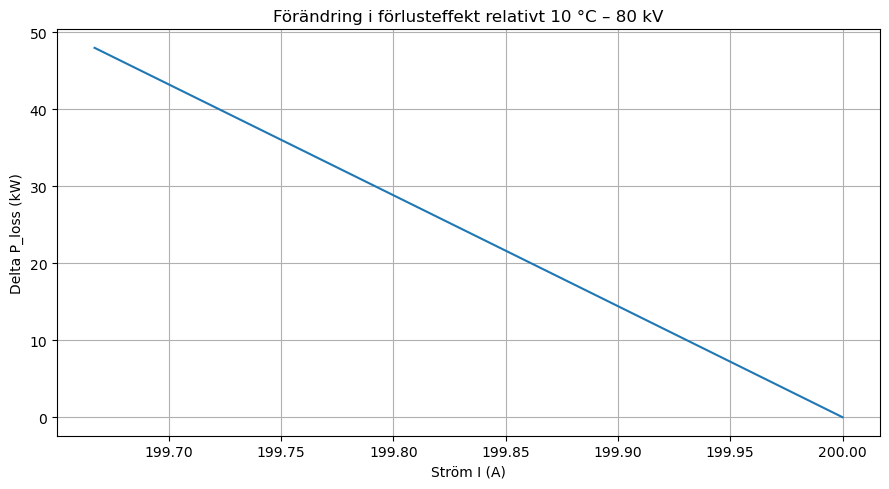

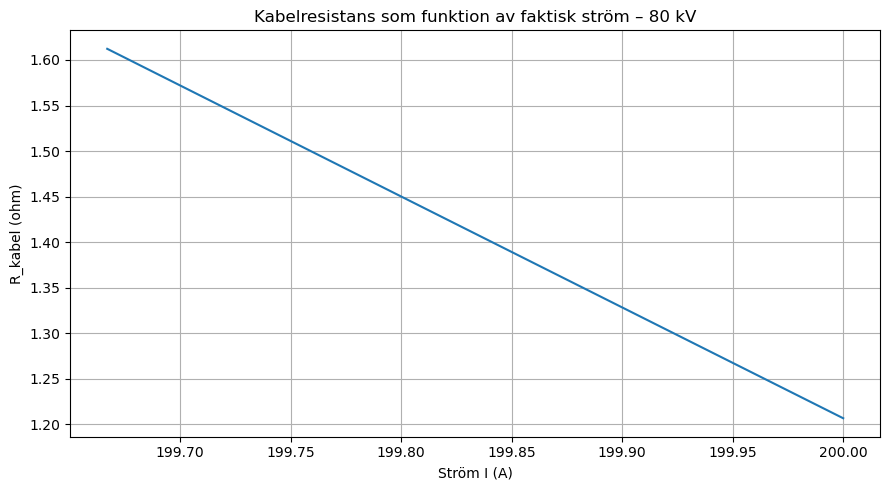


Klart. Alla figurer är nu separerade per spänningsnivå.


In [2]:
# ============================================================
# FRAMÅTRIKTAD LÄNKMODELL MED FAST LAST
# STRÖM PÅ X-AXELN - SEPARATA FIGURER FÖR 0.4 kV, 11 kV, 80 kV
#
# Syfte:
#   Visa hur mottagarspänning, fasvinkel, ström och förlusteffekt
#   ändras när kabelns resistans ändras med temperaturen.
#
# Modell:
#   Vs = I * (Z_cable(T) + Z_load)
#   Vr = I * Z_load
#   I(T) = Vs / (Z_cable(T) + Z_load)
#
# Antaganden:
#   - balanserad trefas
#   - fast lastimpedans Z_load
#   - kabelreaktans X konstant
#   - kabelresistans R(T) temperaturberoende
#
# Skillnad här:
#   - X-axeln är faktisk ström I(A)
#   - varje spänningsnivå får sina egna figurer
# ============================================================

import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

# ============================================================
# HJÄLPFUNKTIONER
# ============================================================

def safe_folder_name(name):
    return re.sub(r'[<>:"/\\|?*]', '_', name).strip().rstrip(".")

def polar(mag, ang_deg):
    return mag * np.exp(1j * np.deg2rad(ang_deg))

def angle_deg(z):
    return np.rad2deg(np.angle(z))

# ============================================================
# PARAMETRAR
# ============================================================

alpha = 0.00403
T_min = 10
T_max = 90

# ============================================================
# FAST LASTMODELL
# ============================================================

def run_case_fixed_load(label, U_LL_s, I_A_10, cosphi_10, R20_cable, X_cable, T_min=10, T_max=90):
    """
    Modell:
        Vs = I*(Z_cable(T) + Z_load)
        Vr = I*Z_load
        I(T) = Vs / (Z_cable(T) + Z_load)

    Steg:
    1) Välj driftfall vid 10 °C: U_LL,s, I, cosphi
    2) Beräkna kabelimpedans vid 10 °C
    3) Beräkna Z_load så att driftfallet stämmer vid 10 °C
    4) Håll Z_load konstant när kabelns R(T) ändras
    """

    # Sändarsidan som referens
    Vs = polar(U_LL_s / np.sqrt(3), 0.0)

    # Effektfaktorvinkel vid 10 °C
    phi10_deg = np.degrees(np.arccos(cosphi_10))

    # Ström vid 10 °C
    I10 = polar(I_A_10, -phi10_deg)

    # Kabel vid 10 °C
    R10 = R20_cable * (1 + alpha * (10 - 20.0))
    Zc10 = R10 + 1j * X_cable

    # Mottagarspänning vid 10 °C
    Vr10 = Vs - Zc10 * I10

    # Fast lastimpedans som gör att driftfallet stämmer vid 10 °C
    Zload = Vr10 / I10

    rows = []
    for T in range(T_min, T_max + 1):
        Rc = R20_cable * (1 + alpha * (T - 20.0))
        Zc = Rc + 1j * X_cable

        # Exakt lösning
        I = Vs / (Zc + Zload)
        Vr = I * Zload

        # Sändar- och mottagareffekt
        Ss = 3 * Vs * np.conj(I)
        Sr = 3 * Vr * np.conj(I)

        Ps = np.real(Ss)
        Qs = np.imag(Ss)
        Pr = np.real(Sr)
        Qr = np.imag(Sr)

        # Trefasförlust
        P_loss = Ps - Pr

        # Lokal fasvinkel på sändarsidan
        phi_s_deg = angle_deg(Vs) - angle_deg(I)

        # Lokal fasvinkel på mottagarsidan
        phi_r_deg = angle_deg(Vr) - angle_deg(I)

        rows.append({
            "Exempel": label,
            "T_C": T,
            "U_LL_s_V": U_LL_s,
            "I_A_exact": abs(I),
            "I_ang_deg_exact": angle_deg(I),
            "phi_s_deg_exact": phi_s_deg,
            "phi_r_deg_exact": phi_r_deg,
            "cosphi_s_exact": np.cos(np.deg2rad(phi_s_deg)),
            "cosphi_r_exact": np.cos(np.deg2rad(phi_r_deg)),
            "R_cable_Ohm": Rc,
            "X_cable_Ohm": X_cable,
            "R_load_Ohm": np.real(Zload),
            "X_load_Ohm": np.imag(Zload),
            "Vr_LL_exact_V": abs(Vr) * np.sqrt(3),
            "Vr_ang_exact_deg": angle_deg(Vr),
            "P_send_W": Ps,
            "Q_send_var": Qs,
            "P_rec_W": Pr,
            "Q_rec_var": Qr,
            "P_loss_W": P_loss,
        })

    df = pd.DataFrame(rows)

    row10 = df[df["T_C"] == 10].iloc[0]
    row90 = df[df["T_C"] == 90].iloc[0]

    print(f"\n=== {label} ===")
    print(f"U_LL,s = {U_LL_s:.1f} V")
    print(f"I(10°C) = {I_A_10:.1f} A")
    print(f"cos(phi)(10°C) = {cosphi_10:.3f}")
    print(f"R20_kabel = {R20_cable:.6f} ohm")
    print(f"X_kabel = {X_cable:.6f} ohm")
    print(f"Beräknad fast last: Z_load = {np.real(Zload):.6f} + j{np.imag(Zload):.6f} ohm")

    print("\nVid 10 °C:")
    print(f"  R_kabel(10)      = {row10['R_cable_Ohm']:.6f} ohm")
    print(f"  I_exact(10)      = {row10['I_A_exact']:.6f} A")
    print(f"  Vr_LL_exact(10)  = {row10['Vr_LL_exact_V']:.2f} V")
    print(f"  Vr_ang_exact(10) = {row10['Vr_ang_exact_deg']:.6f} deg")
    print(f"  P_loss(10)       = {row10['P_loss_W']:.2f} W")

    print("\nVid 90 °C:")
    print(f"  R_kabel(90)      = {row90['R_cable_Ohm']:.6f} ohm")
    print(f"  I_exact(90)      = {row90['I_A_exact']:.6f} A")
    print(f"  Vr_LL_exact(90)  = {row90['Vr_LL_exact_V']:.2f} V")
    print(f"  Vr_ang_exact(90) = {row90['Vr_ang_exact_deg']:.6f} deg")
    print(f"  P_loss(90)       = {row90['P_loss_W']:.2f} W")

    print("\nSkillnad 10 -> 90 °C:")
    print(f"  Delta I          = {row90['I_A_exact'] - row10['I_A_exact']:.6f} A")
    print(f"  Delta Vr_LL      = {row90['Vr_LL_exact_V'] - row10['Vr_LL_exact_V']:.2f} V")
    print(f"  Delta Vr_ang     = {row90['Vr_ang_exact_deg'] - row10['Vr_ang_exact_deg']:.6f} deg")
    print(f"  Delta P_loss     = {row90['P_loss_W'] - row10['P_loss_W']:.2f} W")

    return df, Zload

# ============================================================
# TRE EXEMPEL
# ============================================================

df_04, Zload_04 = run_case_fixed_load(
    label="0.4 kV",
    U_LL_s=400.0,
    I_A_10=200.0,
    cosphi_10=0.95,
    R20_cable=0.030,
    X_cable=0.008,
    T_min=T_min,
    T_max=T_max
)

df_11, Zload_11 = run_case_fixed_load(
    label="11 kV",
    U_LL_s=11000.0,
    I_A_10=200.0,
    cosphi_10=0.95,
    R20_cable=0.800,
    X_cable=0.450,
    T_min=T_min,
    T_max=T_max
)

df_80, Zload_80 = run_case_fixed_load(
    label="80 kV",
    U_LL_s=80000.0,
    I_A_10=200.0,
    cosphi_10=0.95,
    R20_cable=1.2575,
    X_cable=6.555,
    T_min=T_min,
    T_max=T_max
)

# ============================================================
# SAMMANFATTNING
# ============================================================

def pick_summary_fixed(df, label):
    row10 = df[df["T_C"] == 10].iloc[0]
    row90 = df[df["T_C"] == 90].iloc[0]

    delta_T_total = T_max - T_min
    n_5C_steps = delta_T_total / 5.0

    delta_v = row90["Vr_LL_exact_V"] - row10["Vr_LL_exact_V"]
    delta_ang = row90["Vr_ang_exact_deg"] - row10["Vr_ang_exact_deg"]
    delta_i = row90["I_A_exact"] - row10["I_A_exact"]
    delta_i_ang = row90["I_ang_deg_exact"] - row10["I_ang_deg_exact"]
    delta_phi_s = row90["phi_s_deg_exact"] - row10["phi_s_deg_exact"]
    delta_phi_r = row90["phi_r_deg_exact"] - row10["phi_r_deg_exact"]
    delta_p = row90["P_loss_W"] - row10["P_loss_W"]

    return {
        "Exempel": label,
        "R_10_Ohm": row10["R_cable_Ohm"],
        "R_90_Ohm": row90["R_cable_Ohm"],
        "Delta_R_per_5C_Ohm": (row90["R_cable_Ohm"] - row10["R_cable_Ohm"]) / n_5C_steps,

        "Vr_10_V": row10["Vr_LL_exact_V"],
        "Vr_90_V": row90["Vr_LL_exact_V"],
        "Delta_Vr_V": delta_v,
        "Delta_Vr_pct": 100.0 * delta_v / row10["Vr_LL_exact_V"],
        "Delta_Vr_abs_pct": 100.0 * abs(delta_v) / row10["Vr_LL_exact_V"],
        "Delta_Vr_per_5C_V": delta_v / n_5C_steps,
        "Delta_Vr_abs_per_5C_V": abs(delta_v) / n_5C_steps,

        "Vr_ang_10_deg": row10["Vr_ang_exact_deg"],
        "Vr_ang_90_deg": row90["Vr_ang_exact_deg"],
        "Delta_Vr_ang_deg": delta_ang,
        "Delta_Vr_ang_per_5C_deg": delta_ang / n_5C_steps,

        "I_10_A": row10["I_A_exact"],
        "I_90_A": row90["I_A_exact"],
        "Delta_I_A": delta_i,
        "Delta_I_per_5C_A": delta_i / n_5C_steps,

        "I_ang_10_deg": row10["I_ang_deg_exact"],
        "I_ang_90_deg": row90["I_ang_deg_exact"],
        "Delta_I_ang_deg": delta_i_ang,
        "Delta_I_ang_per_5C_deg": delta_i_ang / n_5C_steps,

        "phi_s_10_deg": row10["phi_s_deg_exact"],
        "phi_s_90_deg": row90["phi_s_deg_exact"],
        "Delta_phi_s_deg": delta_phi_s,
        "Delta_phi_s_per_5C_deg": delta_phi_s / n_5C_steps,

        "phi_r_10_deg": row10["phi_r_deg_exact"],
        "phi_r_90_deg": row90["phi_r_deg_exact"],
        "Delta_phi_r_deg": delta_phi_r,
        "Delta_phi_r_per_5C_deg": delta_phi_r / n_5C_steps,

        "P_loss_10_W": row10["P_loss_W"],
        "P_loss_90_W": row90["P_loss_W"],
        "Delta_P_loss_W": delta_p,
        "Delta_P_loss_per_5C_W": delta_p / n_5C_steps,
        "Delta_P_loss_per_5C_kW": delta_p / n_5C_steps / 1000.0,
    }

summary = pd.DataFrame([
    pick_summary_fixed(df_04, "0.4 kV"),
    pick_summary_fixed(df_11, "11 kV"),
    pick_summary_fixed(df_80, "80 kV"),
])

print("\n=== SAMMANFATTNING ===")
print(summary.round(6))

# ============================================================
# SPARA
# ============================================================

VERSION = "10-90_grader_fast_last_current_axis_separate_cases"
output_dir = Path(r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data") / safe_folder_name(VERSION)
output_dir.mkdir(parents=True, exist_ok=True)

summary.to_excel(output_dir / "summary_fast_last_current_axis_separate.xlsx", index=False)
summary.to_csv(output_dir / "summary_fast_last_current_axis_separate.csv", index=False)

df_04.to_excel(output_dir / "case_fixed_load_0_4kV.xlsx", index=False)
df_11.to_excel(output_dir / "case_fixed_load_11kV.xlsx", index=False)
df_80.to_excel(output_dir / "case_fixed_load_80kV.xlsx", index=False)

print("\nSparat till:", output_dir.resolve())

# ============================================================
# FIGURER - ENDAST EN SPÄNNINGSNIVÅ PER FIGUR
# ============================================================

cases = [
    ("0.4 kV", df_04, "0_4kV"),
    ("11 kV", df_11, "11kV"),
    ("80 kV", df_80, "80kV"),
]

for label, df_case, tag in cases:
    # Sortera på faktisk ström så att kurvorna blir mer lättlästa
    df_plot = df_case.sort_values("I_A_exact").copy()

    I = df_plot["I_A_exact"]

    # Referensvärden vid 10 °C
    row10 = df_case[df_case["T_C"] == 10].iloc[0]
    Vr0 = row10["Vr_LL_exact_V"]
    ang0 = row10["Vr_ang_exact_deg"]
    P0 = row10["P_loss_W"]

    # Deriverade storheter
    delta_V = df_plot["Vr_LL_exact_V"] - Vr0
    delta_V_pct = 100.0 * (df_plot["Vr_LL_exact_V"] - Vr0) / Vr0
    delta_ang = df_plot["Vr_ang_exact_deg"] - ang0
    delta_P_loss_kW = (df_plot["P_loss_W"] - P0) / 1000.0
    P_loss_kW = df_plot["P_loss_W"] / 1000.0

    # 1. Exakt mottagarspänning
    plt.figure(figsize=(9, 5))
    plt.plot(I, df_plot["Vr_LL_exact_V"])
    plt.title(f"Mottagarspänning som funktion av faktisk ström – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("U_LL,r (V)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir / f"Vr_vs_I_{tag}.png", dpi=200)
    plt.show()

    # 2. Förändring i mottagarspänning relativt 10 °C (V)
    plt.figure(figsize=(9, 5))
    plt.plot(I, delta_V)
    plt.title(f"Förändring i mottagarspänning relativt 10 °C – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("Delta U_LL,r (V)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir / f"Delta_Vr_vs_I_{tag}.png", dpi=200)
    plt.show()

    # 3. Förändring i mottagarspänning relativt 10 °C (%)
    plt.figure(figsize=(9, 5))
    plt.plot(I, delta_V_pct)
    plt.title(f"Förändring i mottagarspänning i procent relativt 10 °C – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("Delta U_LL,r (%)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir / f"Delta_Vr_pct_vs_I_{tag}.png", dpi=200)
    plt.show()

    # 4. Mottagarvinkel
    plt.figure(figsize=(9, 5))
    plt.plot(I, df_plot["Vr_ang_exact_deg"])
    plt.title(f"Mottagarvinkel som funktion av faktisk ström – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("Vinkel V_r (grader)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir / f"Vr_angle_vs_I_{tag}.png", dpi=200)
    plt.show()

    # 5. Förändring i mottagarvinkel relativt 10 °C
    plt.figure(figsize=(9, 5))
    plt.plot(I, delta_ang)
    plt.title(f"Förändring i mottagarvinkel relativt 10 °C – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("Delta vinkel V_r (grader)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir / f"Delta_Vr_angle_vs_I_{tag}.png", dpi=200)
    plt.show()

    # 6. Temperatur som funktion av faktisk ström
    plt.figure(figsize=(9, 5))
    plt.plot(I, df_plot["T_C"])
    plt.title(f"Temperatur som funktion av faktisk ström – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("Temperatur (°C)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir / f"T_vs_I_{tag}.png", dpi=200)
    plt.show()

    # 7. Strömvinkel
    plt.figure(figsize=(9, 5))
    plt.plot(I, df_plot["I_ang_deg_exact"])
    plt.title(f"Strömvinkel som funktion av faktisk ström – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("I-vinkel (grader)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir / f"I_angle_vs_I_{tag}.png", dpi=200)
    plt.show()

    # 8. Lokal fasvinkel phi_s
    plt.figure(figsize=(9, 5))
    plt.plot(I, df_plot["phi_s_deg_exact"])
    plt.title(f"Fasvinkel på sändarsidan som funktion av faktisk ström – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("phi_s (grader)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir / f"phi_s_vs_I_{tag}.png", dpi=200)
    plt.show()

    # 9. Förlusteffekt
    plt.figure(figsize=(9, 5))
    plt.plot(I, P_loss_kW)
    plt.title(f"Förlusteffekt som funktion av faktisk ström – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("P_loss (kW)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir / f"Ploss_vs_I_{tag}.png", dpi=200)
    plt.show()

    # 10. Förändring i förlusteffekt relativt 10 °C
    plt.figure(figsize=(9, 5))
    plt.plot(I, delta_P_loss_kW)
    plt.title(f"Förändring i förlusteffekt relativt 10 °C – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("Delta P_loss (kW)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir / f"Delta_Ploss_vs_I_{tag}.png", dpi=200)
    plt.show()

    # 11. Kabelresistans
    plt.figure(figsize=(9, 5))
    plt.plot(I, df_plot["R_cable_Ohm"])
    plt.title(f"Kabelresistans som funktion av faktisk ström – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel("R_kabel (ohm)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir / f"R_vs_I_{tag}.png", dpi=200)
    plt.show()

print("\nKlart. Alla figurer är nu separerade per spänningsnivå.")


=== 0.4 kV ===
U_LL,s = 400.0 V
I(10 °C) = 200.0 A
cos(phi)(10 °C) = 0.950
R20_kabel = 0.030000 ohm
X_kabel = 0.008000 ohm
Beräknad fast last: Z_load = 1.068175 + j0.352555 ohm

Skillnad 10 -> 90 °C:
  Delta I      = -1.579582 A
  Delta Vr     = -3.08 V
  Delta vinkel = 0.148672 grader
  Delta P_loss = 1.088 kW

=== 11 kV ===
U_LL,s = 11000.0 V
I(10 °C) = 200.0 A
cos(phi)(10 °C) = 0.950
R20_kabel = 0.800000 ohm
X_kabel = 0.450000 ohm
Beräknad fast last: Z_load = 29.398792 + j9.465266 ohm

Skillnad 10 -> 90 °C:
  Delta I      = -1.532063 A
  Delta Vr     = -81.96 V
  Delta vinkel = 0.144201 grader
  Delta P_loss = 29.072 kW

=== 80 kV ===
U_LL,s = 80000.0 V
I(10 °C) = 200.0 A
cos(phi)(10 °C) = 0.950
R20_kabel = 1.257500 ohm
X_kabel = 6.555000 ohm
Beräknad fast last: Z_load = 218.186280 + j65.556026 ohm

Skillnad 10 -> 90 °C:
  Delta I      = -0.333022 A
  Delta Vr     = -131.41 V
  Delta vinkel = 0.031355 grader
  Delta P_loss = 48.006 kW

=== SAMMANFATTNING ===
  Exempel  I_10C_A     

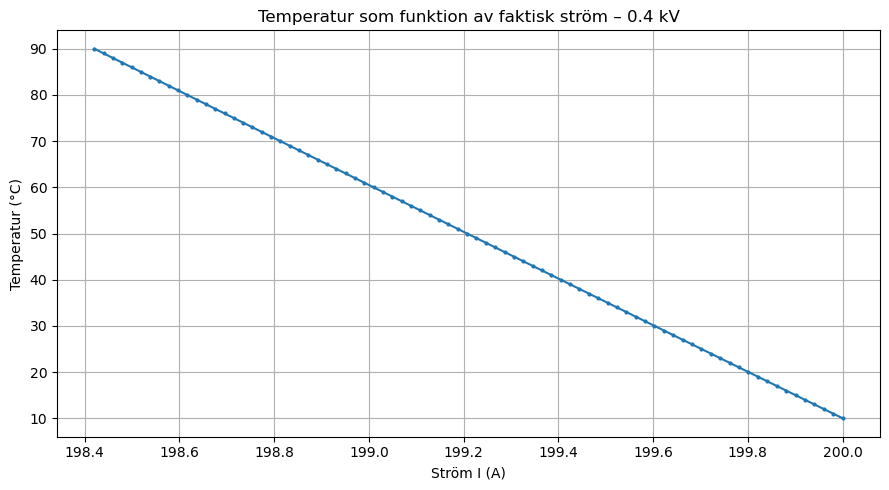

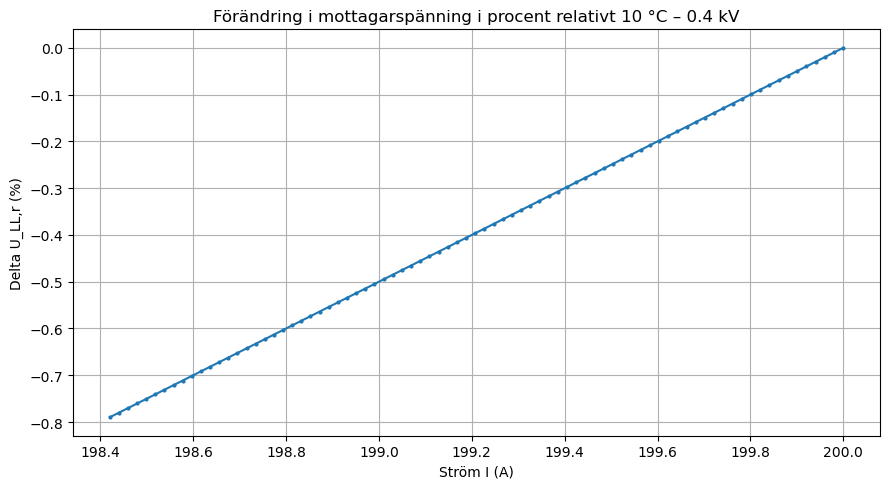

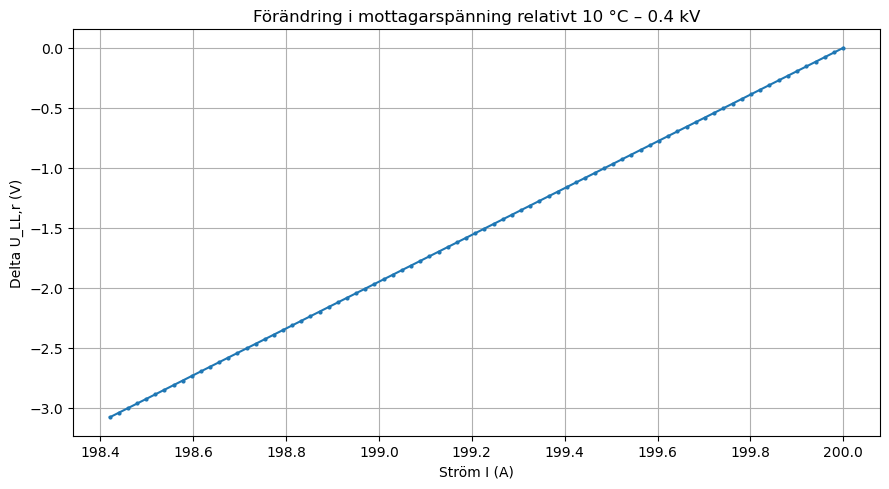

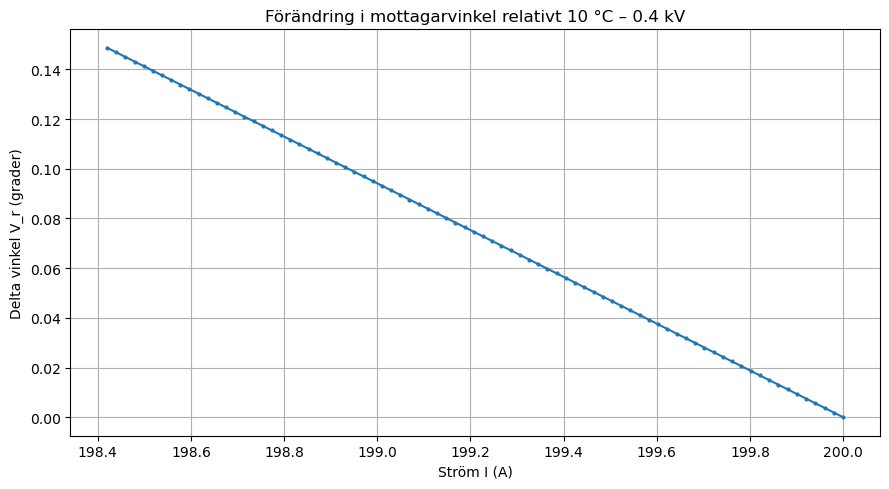

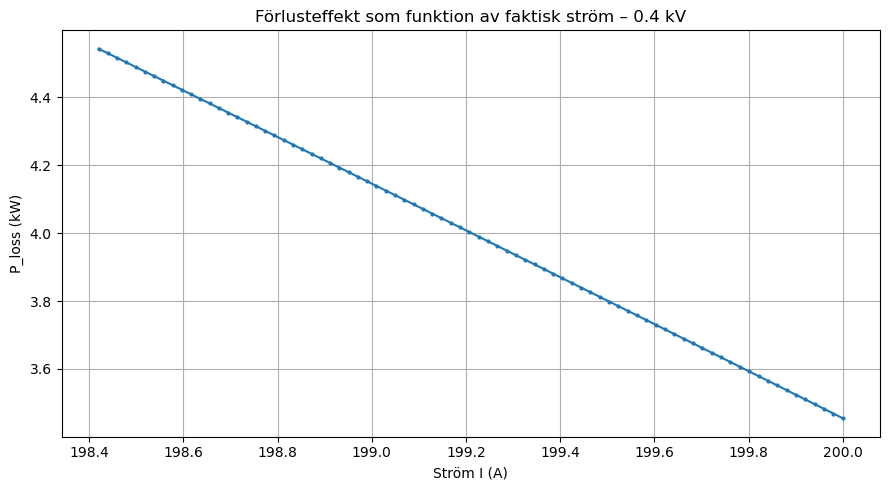

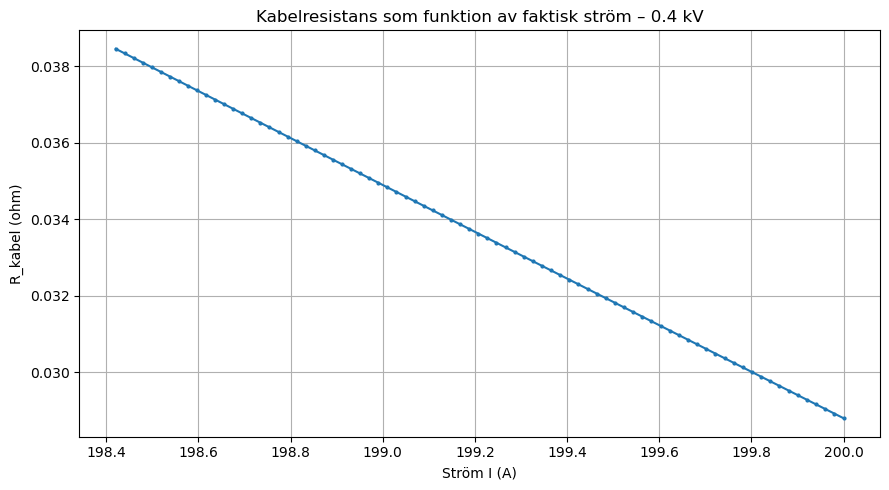

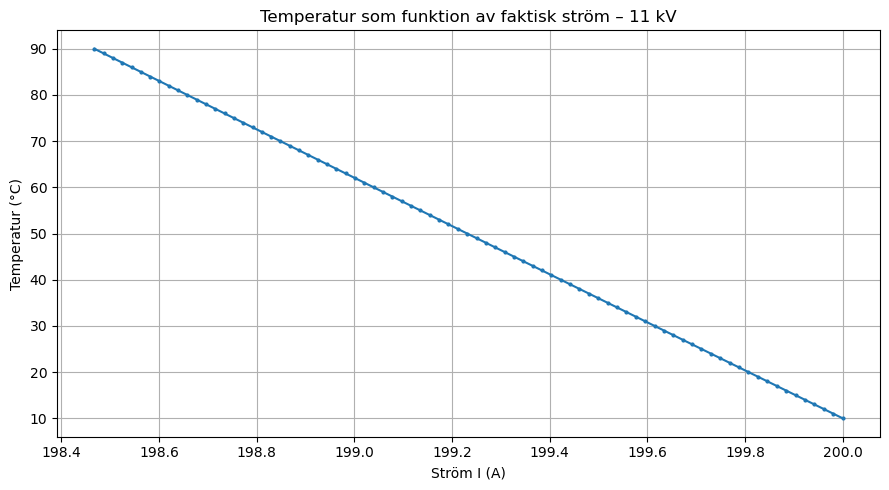

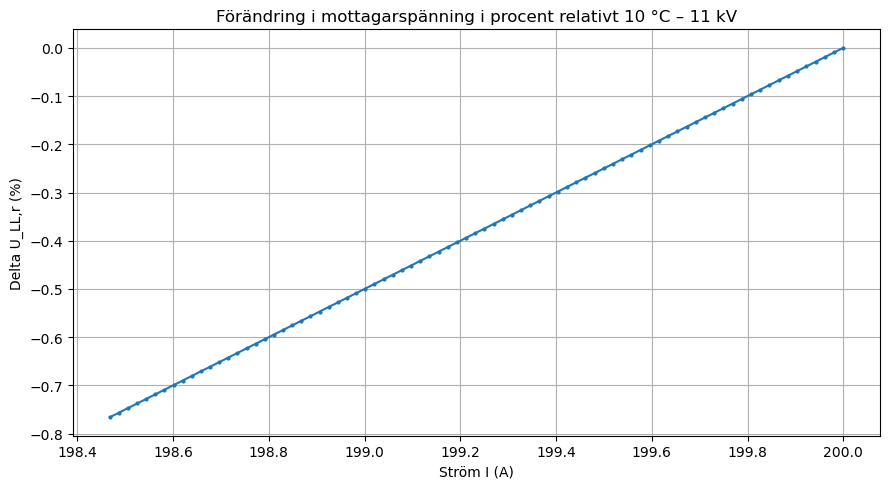

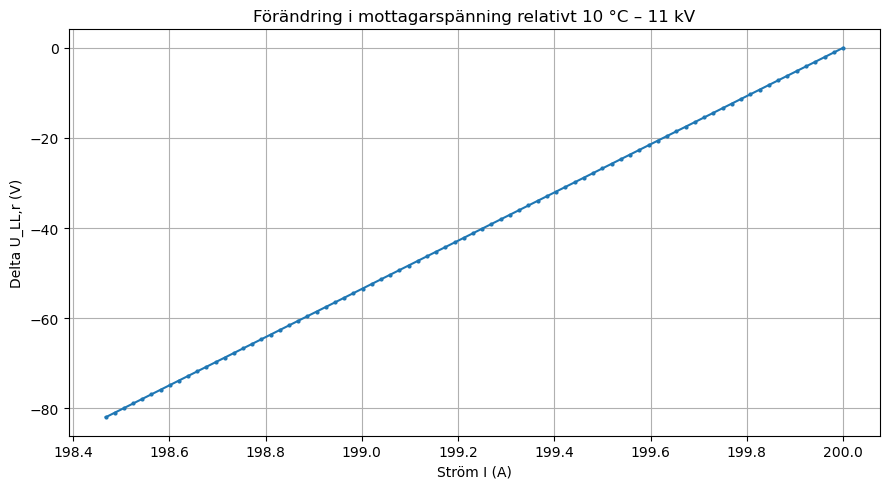

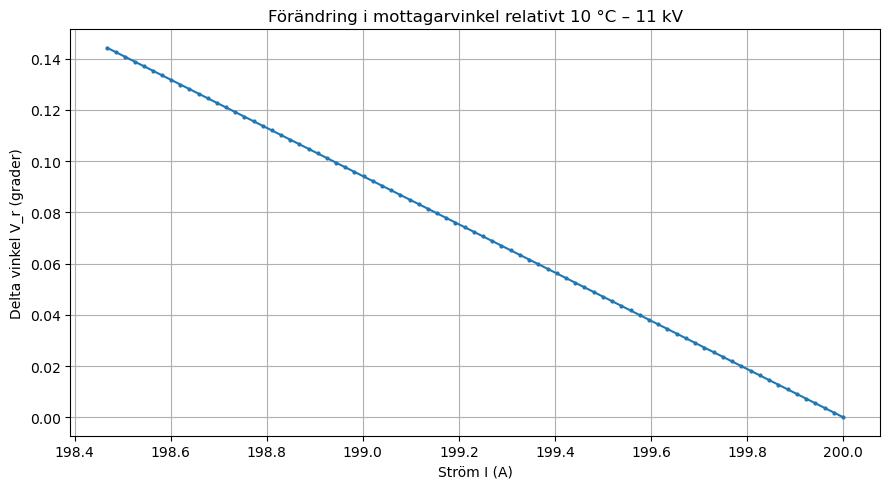

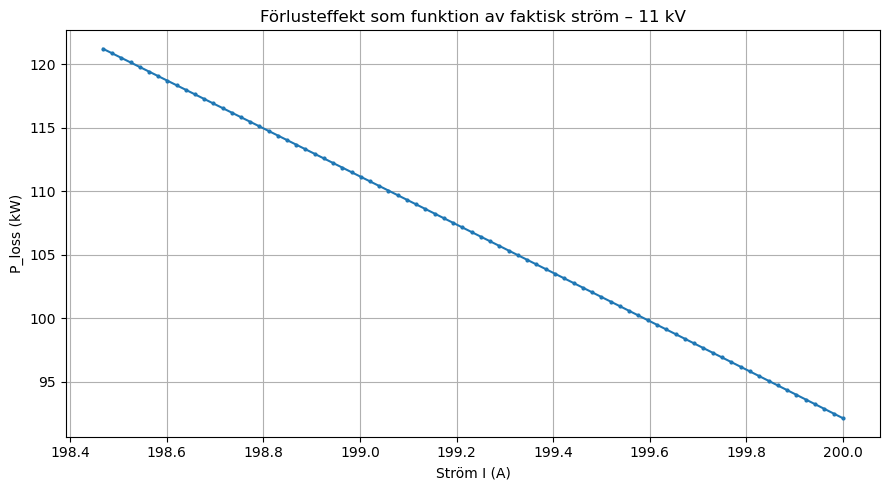

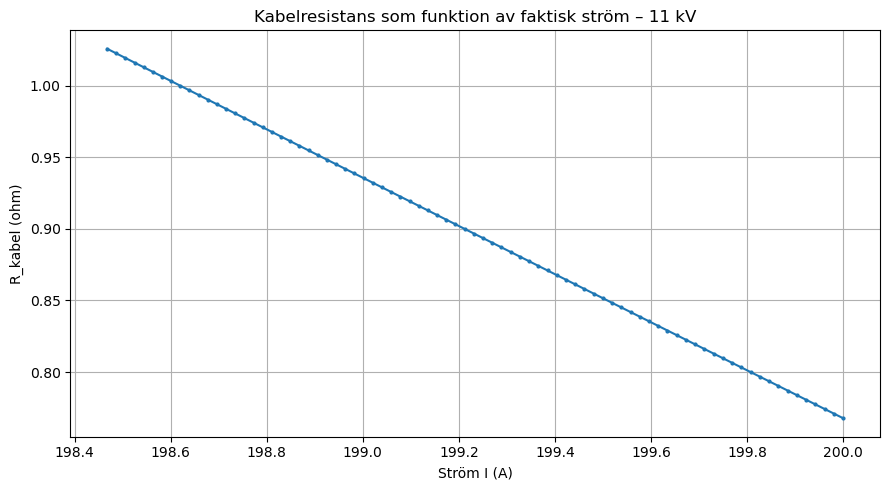

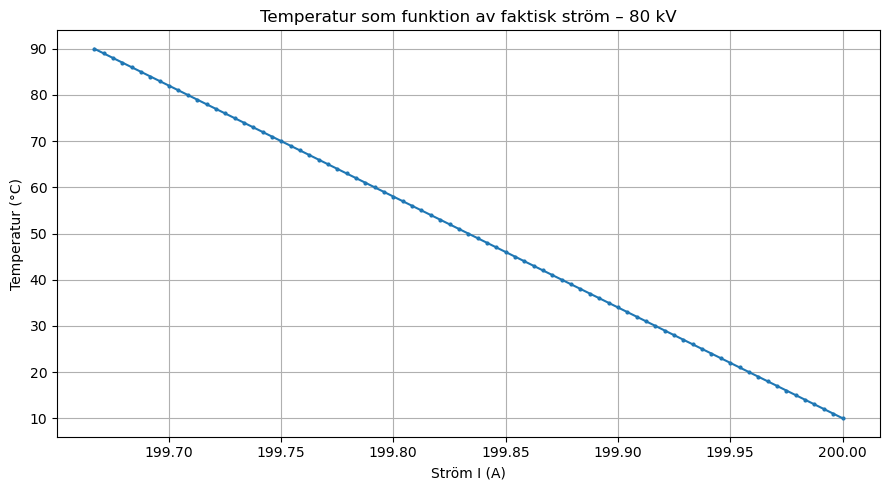

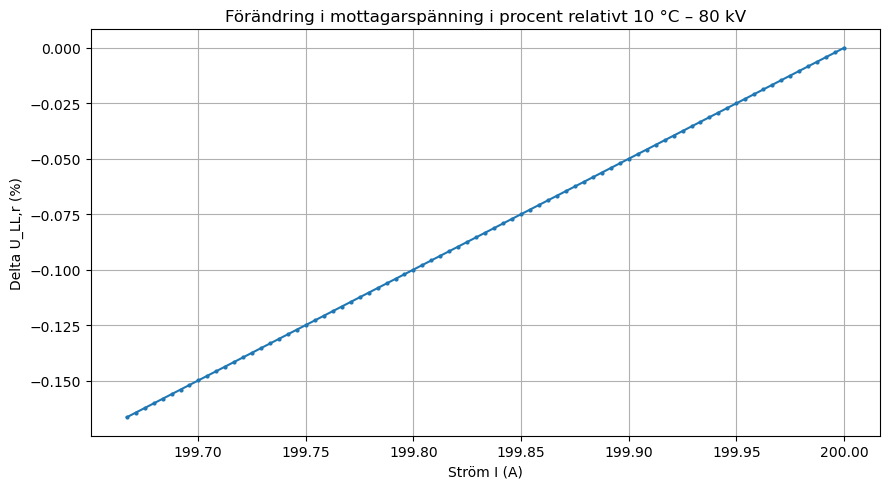

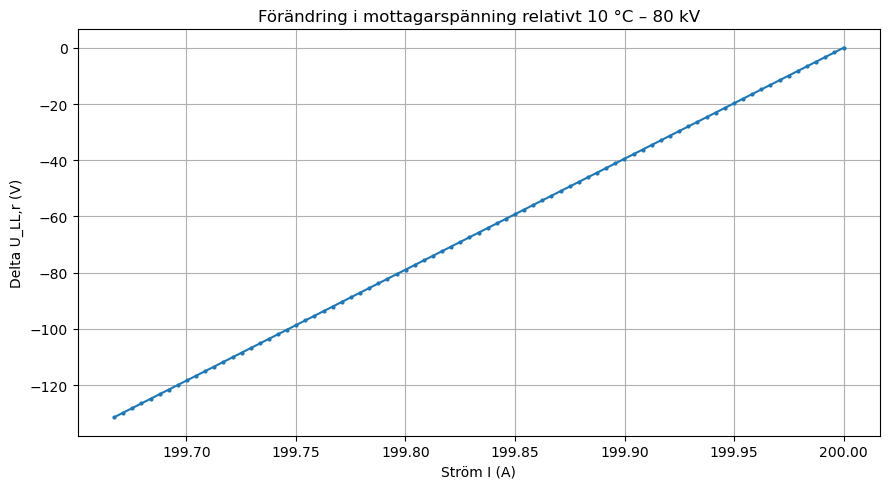

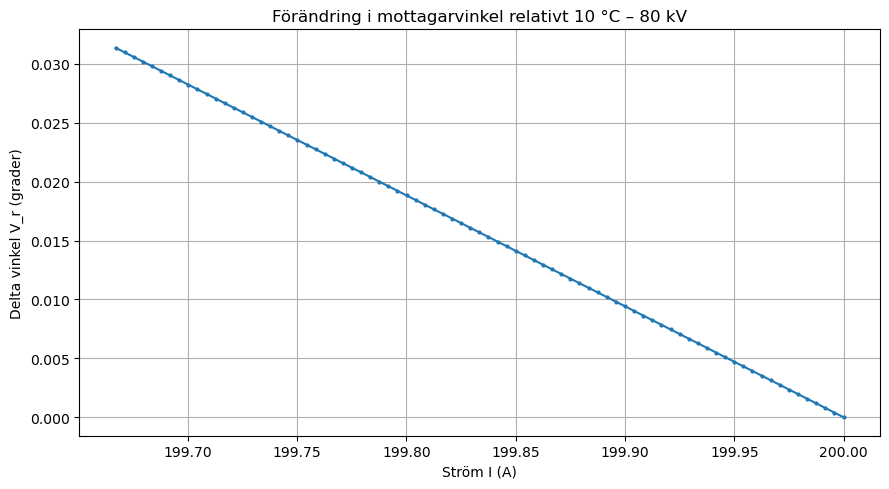

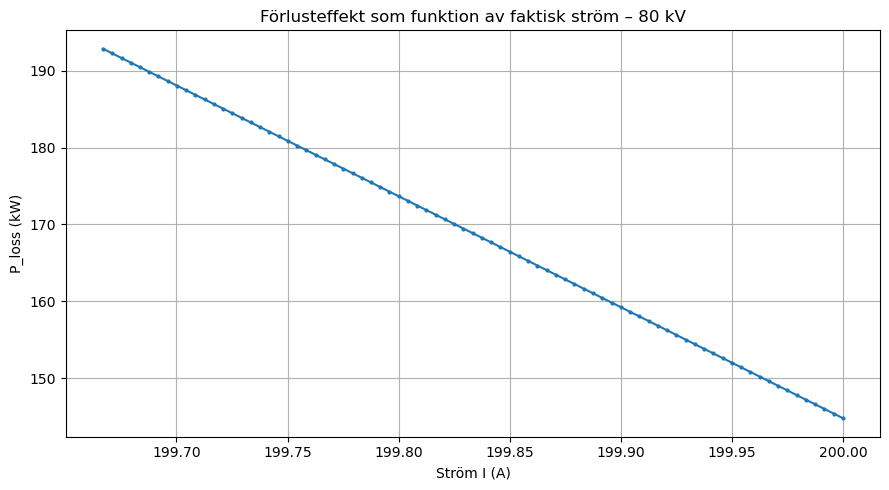

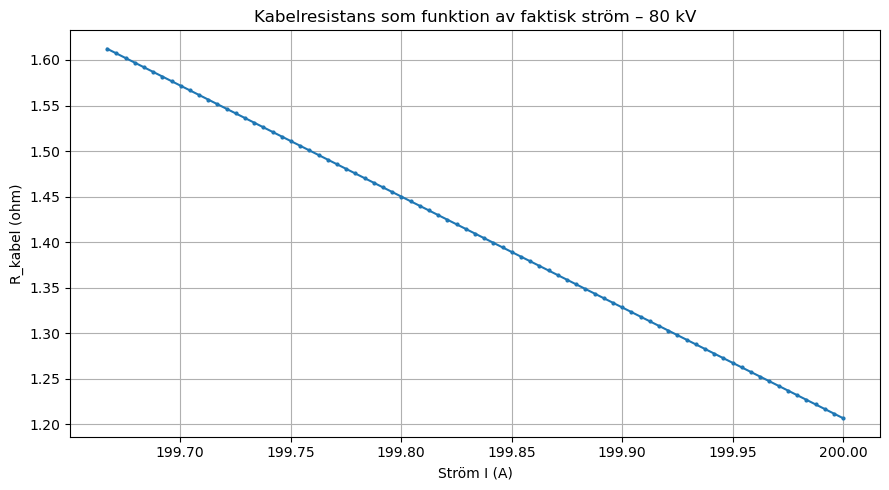


Klart. Figurer och tabeller sparade till:
C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\10-90_grader_fast_last_current_axis_clean_


In [3]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

# ============================================================
# HJÄLPFUNKTIONER
# ============================================================

def safe_folder_name(name):
    return re.sub(r'[<>:"/\\|?*]', "_", name).strip().rstrip(".")

def polar(mag, ang_deg):
    return mag * np.exp(1j * np.deg2rad(ang_deg))

def angle_deg(z):
    return np.rad2deg(np.angle(z))

# ============================================================
# PARAMETRAR
# ============================================================

alpha = 0.00403
T_min = 10
T_max = 90

# ============================================================
# FAST LASTMODELL
# ============================================================

def run_case_fixed_load(label, U_LL_s, I_A_10, cosphi_10, R20_cable, X_cable, T_min=10, T_max=90):
    """
    Fast lastmodell.

    Temperaturen är indata.
    Strömmen blir ett resultat av:
    - konstant sändarspänning
    - fast lastimpedans
    - temperaturberoende kabelresistans
    """

    Vs = polar(U_LL_s / np.sqrt(3), 0.0)

    phi10_deg = np.degrees(np.arccos(cosphi_10))
    I10 = polar(I_A_10, -phi10_deg)

    R10 = R20_cable * (1 + alpha * (10 - 20.0))
    Zc10 = R10 + 1j * X_cable

    Vr10 = Vs - Zc10 * I10

    Zload = Vr10 / I10

    rows = []

    for T in range(T_min, T_max + 1):
        Rc = R20_cable * (1 + alpha * (T - 20.0))
        Zc = Rc + 1j * X_cable

        I = Vs / (Zc + Zload)
        Vr = I * Zload

        Ss = 3 * Vs * np.conj(I)
        Sr = 3 * Vr * np.conj(I)

        Ps = np.real(Ss)
        Qs = np.imag(Ss)
        Pr = np.real(Sr)
        Qr = np.imag(Sr)

        P_loss = Ps - Pr

        phi_s_deg = angle_deg(Vs) - angle_deg(I)
        phi_r_deg = angle_deg(Vr) - angle_deg(I)

        rows.append({
            "Exempel": label,
            "T_C": T,
            "U_LL_s_V": U_LL_s,
            "I_A_exact": abs(I),
            "I_ang_deg_exact": angle_deg(I),
            "phi_s_deg_exact": phi_s_deg,
            "phi_r_deg_exact": phi_r_deg,
            "cosphi_s_exact": np.cos(np.deg2rad(phi_s_deg)),
            "cosphi_r_exact": np.cos(np.deg2rad(phi_r_deg)),
            "R_cable_Ohm": Rc,
            "X_cable_Ohm": X_cable,
            "R_load_Ohm": np.real(Zload),
            "X_load_Ohm": np.imag(Zload),
            "Vr_LL_exact_V": abs(Vr) * np.sqrt(3),
            "Vr_ang_exact_deg": angle_deg(Vr),
            "P_send_W": Ps,
            "Q_send_var": Qs,
            "P_rec_W": Pr,
            "Q_rec_var": Qr,
            "P_loss_W": P_loss,
            "P_loss_kW": P_loss / 1000.0,
        })

    df = pd.DataFrame(rows)

    row10 = df[df["T_C"] == 10].iloc[0]
    row90 = df[df["T_C"] == 90].iloc[0]

    print(f"\n=== {label} ===")
    print(f"U_LL,s = {U_LL_s:.1f} V")
    print(f"I(10 °C) = {I_A_10:.1f} A")
    print(f"cos(phi)(10 °C) = {cosphi_10:.3f}")
    print(f"R20_kabel = {R20_cable:.6f} ohm")
    print(f"X_kabel = {X_cable:.6f} ohm")
    print(f"Beräknad fast last: Z_load = {np.real(Zload):.6f} + j{np.imag(Zload):.6f} ohm")

    print("\nSkillnad 10 -> 90 °C:")
    print(f"  Delta I      = {row90['I_A_exact'] - row10['I_A_exact']:.6f} A")
    print(f"  Delta Vr     = {row90['Vr_LL_exact_V'] - row10['Vr_LL_exact_V']:.2f} V")
    print(f"  Delta vinkel = {row90['Vr_ang_exact_deg'] - row10['Vr_ang_exact_deg']:.6f} grader")
    print(f"  Delta P_loss = {(row90['P_loss_W'] - row10['P_loss_W']) / 1000:.3f} kW")

    return df, Zload

# ============================================================
# KÖR TRE FALL
# ============================================================

df_04, Zload_04 = run_case_fixed_load(
    label="0.4 kV",
    U_LL_s=400.0,
    I_A_10=200.0,
    cosphi_10=0.95,
    R20_cable=0.030,
    X_cable=0.008,
    T_min=T_min,
    T_max=T_max
)

df_11, Zload_11 = run_case_fixed_load(
    label="11 kV",
    U_LL_s=11000.0,
    I_A_10=200.0,
    cosphi_10=0.95,
    R20_cable=0.800,
    X_cable=0.450,
    T_min=T_min,
    T_max=T_max
)

df_80, Zload_80 = run_case_fixed_load(
    label="80 kV",
    U_LL_s=80000.0,
    I_A_10=200.0,
    cosphi_10=0.95,
    R20_cable=1.2575,
    X_cable=6.555,
    T_min=T_min,
    T_max=T_max
)

# ============================================================
# LÄGG TILL RELATIVA KOLUMNER
# ============================================================

def add_relative_columns(df):
    df = df.copy()

    row10 = df[df["T_C"] == 10].iloc[0]

    df["Delta_Vr_V_rel_10C"] = df["Vr_LL_exact_V"] - row10["Vr_LL_exact_V"]
    df["Delta_Vr_pct_rel_10C"] = 100.0 * df["Delta_Vr_V_rel_10C"] / row10["Vr_LL_exact_V"]
    df["Delta_Vr_ang_deg_rel_10C"] = df["Vr_ang_exact_deg"] - row10["Vr_ang_exact_deg"]
    df["Delta_P_loss_kW_rel_10C"] = (df["P_loss_W"] - row10["P_loss_W"]) / 1000.0
    df["Delta_R_Ohm_rel_10C"] = df["R_cable_Ohm"] - row10["R_cable_Ohm"]

    df = df.sort_values("I_A_exact").reset_index(drop=True)

    return df

plot_04 = add_relative_columns(df_04)
plot_11 = add_relative_columns(df_11)
plot_80 = add_relative_columns(df_80)

cases = [
    ("0.4 kV", plot_04, "0_4kV"),
    ("11 kV", plot_11, "11kV"),
    ("80 kV", plot_80, "80kV"),
]

# ============================================================
# SPARA
# ============================================================

VERSION = "10-90_grader_fast_last_current_axis_clean_"

output_dir = Path(
    r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data"
) / safe_folder_name(VERSION)

output_dir.mkdir(parents=True, exist_ok=True)

plot_04.to_excel(output_dir / "case_current_axis_0_4kV.xlsx", index=False)
plot_11.to_excel(output_dir / "case_current_axis_11kV.xlsx", index=False)
plot_80.to_excel(output_dir / "case_current_axis_80kV.xlsx", index=False)

# ============================================================
# SAMMANFATTNING
# ============================================================

summary_rows = []

for label, df_case, tag in cases:
    row10 = df_case[df_case["T_C"] == 10].iloc[0]
    row90 = df_case[df_case["T_C"] == 90].iloc[0]

    summary_rows.append({
        "Exempel": label,
        "I_10C_A": row10["I_A_exact"],
        "I_90C_A": row90["I_A_exact"],
        "Delta_I_A": row90["I_A_exact"] - row10["I_A_exact"],
        "Delta_Vr_V": row90["Delta_Vr_V_rel_10C"],
        "Delta_Vr_pct": row90["Delta_Vr_pct_rel_10C"],
        "Delta_Vr_angle_deg": row90["Delta_Vr_ang_deg_rel_10C"],
        "P_loss_10C_kW": row10["P_loss_kW"],
        "P_loss_90C_kW": row90["P_loss_kW"],
        "Delta_P_loss_kW": row90["Delta_P_loss_kW_rel_10C"],
        "R_10C_Ohm": row10["R_cable_Ohm"],
        "R_90C_Ohm": row90["R_cable_Ohm"],
    })

summary_current_axis = pd.DataFrame(summary_rows)

print("\n=== SAMMANFATTNING ===")
print(summary_current_axis.round(6))

summary_current_axis.to_excel(output_dir / "summary_current_axis_clean.xlsx", index=False)
summary_current_axis.to_csv(output_dir / "summary_current_axis_clean.csv", index=False)

# ============================================================
# PLOTTFUNKTION
# ============================================================

def plot_one_case(df_case, label, tag, y_col, title, ylabel, filename):
    plt.figure(figsize=(9, 5))
    plt.plot(df_case["I_A_exact"], df_case[y_col], marker="o", markersize=2)
    plt.title(f"{title} – {label}")
    plt.xlabel("Ström I (A)")
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir / f"{filename}_{tag}.png", dpi=200)
    plt.show()

# ============================================================
# SEPARATA FIGURER PER SPÄNNINGSNIVÅ
# ============================================================

for label, df_case, tag in cases:

    # 1. Temperatur mot faktisk ström
    plot_one_case(
        df_case=df_case,
        label=label,
        tag=tag,
        y_col="T_C",
        title="Temperatur som funktion av faktisk ström",
        ylabel="Temperatur (°C)",
        filename="T_vs_I"
    )

    # 2. Spänningsändring i procent mot faktisk ström
    plot_one_case(
        df_case=df_case,
        label=label,
        tag=tag,
        y_col="Delta_Vr_pct_rel_10C",
        title="Förändring i mottagarspänning i procent relativt 10 °C",
        ylabel="Delta U_LL,r (%)",
        filename="Delta_Vr_pct_vs_I"
    )

    # 3. Spänningsändring i volt mot faktisk ström
    plot_one_case(
        df_case=df_case,
        label=label,
        tag=tag,
        y_col="Delta_Vr_V_rel_10C",
        title="Förändring i mottagarspänning relativt 10 °C",
        ylabel="Delta U_LL,r (V)",
        filename="Delta_Vr_V_vs_I"
    )

    # 4. Mottagarvinkeländring mot faktisk ström
    plot_one_case(
        df_case=df_case,
        label=label,
        tag=tag,
        y_col="Delta_Vr_ang_deg_rel_10C",
        title="Förändring i mottagarvinkel relativt 10 °C",
        ylabel="Delta vinkel V_r (grader)",
        filename="Delta_Vr_angle_vs_I"
    )

    # 5. Förlusteffekt mot faktisk ström
    plot_one_case(
        df_case=df_case,
        label=label,
        tag=tag,
        y_col="P_loss_kW",
        title="Förlusteffekt som funktion av faktisk ström",
        ylabel="P_loss (kW)",
        filename="P_loss_vs_I"
    )

    # 6. Kabelresistans mot faktisk ström
    plot_one_case(
        df_case=df_case,
        label=label,
        tag=tag,
        y_col="R_cable_Ohm",
        title="Kabelresistans som funktion av faktisk ström",
        ylabel="R_kabel (ohm)",
        filename="R_vs_I"
    )

print("\nKlart. Figurer och tabeller sparade till:")
print(output_dir.resolve())